In [1]:
import os
import sys
import time
import subprocess

print(subprocess.run("nvidia-smi --id=0 --query-gpu=memory.used --format=csv,noheader",
                     shell=True, capture_output=True, text=True).stdout)
subprocess.run('pkill -9 -f "[q]uantize.py"', shell=True)

SNIPPETS = {
    "A_device_map_fp16": "m = AutoModelForCausalLM.from_pretrained(ID, dtype=torch.float16, device_map={'': 0})",
    "B_cpu_then_cuda_fp16": "m = AutoModelForCausalLM.from_pretrained(ID, dtype=torch.float16).to('cuda')",
    "C_device_map_nf4": (
        "m = AutoModelForCausalLM.from_pretrained(ID, device_map={'': 0}, "
        "quantization_config=BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type='nf4', "
        "bnb_4bit_compute_dtype=torch.float16))"
    ),
}
HEADER = ("import torch, time\n"
          "from transformers import AutoModelForCausalLM, BitsAndBytesConfig\n"
          "ID = 'Qwen/Qwen2.5-1.5B-Instruct'\n"
          "t = time.time()\n")

for name, body in SNIPPETS.items():
    code = HEADER + body + "\nprint('LOADED', round(time.time() - t, 1), 's')"
    t0 = time.time()
    try:
        r = subprocess.run([sys.executable, "-c", code], capture_output=True, text=True, timeout=150)
        ok = "LOADED" in r.stdout
        print(name, "OK" if ok else "FAILED", round(time.time() - t0, 1), "s",
              "" if ok else r.stderr[-500:], flush=True)
    except subprocess.TimeoutExpired:
        print(name, "TIMEOUT after 150 s (hang)", flush=True)

0 MiB

A_device_map_fp16 OK 63.6 s 
B_cpu_then_cuda_fp16 OK 12.7 s 
C_device_map_nf4 FAILED 9.7 s e_map = get_hf_quantizer(
                                       ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/quantizers/auto.py", line 326, in get_hf_quantizer
    hf_quantizer.validate_environment(
  File "/usr/local/lib/python3.12/dist-packages/transformers/quantizers/quantizer_bnb_4bit.py", line 60, in validate_environment
    raise ImportError(
ImportError: Using `bitsandbytes` 4-bit quantization requires bitsandbytes: `pip install -U bitsandbytes>=0.46.1`



In [2]:
import os
import sys
import json
import time
import subprocess
from pathlib import Path

REPO = "https://github.com/eslam-ahmed43/llm-lab.git"
ROOT = Path("/kaggle/working/llm-lab")
if not ROOT.exists():
    subprocess.run(["git", "clone", REPO, str(ROOT)], check=True)
os.chdir(ROOT)
(ROOT / "plots").mkdir(exist_ok=True)

os.environ["HF_HOME"] = "/tmp/hf_cache"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

_clock = Path("/tmp/session_start.txt")
if not _clock.exists():
    _clock.write_text(str(time.time()))
SESSION_START = float(_clock.read_text())
MAX_SESSION_H = 10.5


def hours_used():
    return (time.time() - SESSION_START) / 3600


def check_budget(next_step_h):
    if hours_used() + next_step_h > MAX_SESSION_H:
        raise RuntimeError(f"Time budget: {hours_used():.1f}h used, next step needs ~{next_step_h}h")


print(subprocess.run("nvidia-smi --query-gpu=name,memory.total --format=csv,noheader",
                     shell=True, capture_output=True, text=True).stdout)
print(subprocess.run("git log --oneline -1", shell=True, capture_output=True, text=True).stdout)

Cloning into '/kaggle/working/llm-lab'...


Tesla T4, 15360 MiB
Tesla T4, 15360 MiB

0f01b47 Exp 1: serving and batching study on a T4



In [3]:
%%bash
set -e
pip install -q bitsandbytes datasets accelerate
python -c "
import bitsandbytes, transformers, torch
print('bitsandbytes', bitsandbytes.__version__, '| transformers', transformers.__version__, '| torch', torch.__version__)
from datasets import load_dataset
try:
    load_dataset('Salesforce/wikitext', 'wikitext-2-raw-v1', split='test')
except Exception:
    load_dataset('wikitext', 'wikitext-2-raw-v1', split='test')
load_dataset('allenai/ai2_arc', 'ARC-Easy', split='test')
from huggingface_hub import snapshot_download
snapshot_download('Qwen/Qwen2.5-1.5B-Instruct')
print('datasets and model cached')
"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 50.4 MB/s eta 0:00:00
bitsandbytes 0.50.2 | transformers 5.0.0 | torch 2.10.0+cu128
datasets and model cached


Fetching 10 files: 100%|██████████| 10/10 [00:08<00:00,  1.22it/s]


In [4]:
import signal


def run_method(name, method, extra=None, model=None, timeout_s=3000):
    out = ROOT / "results" / f"quant_{name}.json"
    check_budget(0.5)
    log_path = ROOT / "logs" / f"quant_{name}.log"
    log_path.parent.mkdir(exist_ok=True)
    cmd = [sys.executable, "-X", "faulthandler", "-u", str(ROOT / "src/quantize.py"), "run",
           "--method", method, "--name", name, "--out", str(out)]
    if model:
        cmd += ["--model", model]
    cmd += extra or []
    env = {**os.environ, "HF_HUB_DISABLE_PROGRESS_BARS": "1", "PYTHONUNBUFFERED": "1"}

    def new_lines(shown):
        lines = log_path.read_text(errors="replace").splitlines()
        for line in lines[shown:]:
            # Skip progress-bar noise, show everything else
            if line.strip() and "Loading weights" not in line:
                print(line[:300], flush=True)
        return len(lines)

    start, shown = time.time(), 0
    with open(log_path, "w") as log:
        proc = subprocess.Popen(cmd, stdout=log, stderr=subprocess.STDOUT, env=env, cwd=str(ROOT))
        while proc.poll() is None:
            time.sleep(10)
            shown = new_lines(shown)
            if time.time() - start > timeout_s:
                os.kill(proc.pid, signal.SIGABRT)  # faulthandler dumps the stack into the log
                time.sleep(3)
                proc.kill()
                print(log_path.read_text(errors="replace")[-3000:])
                raise TimeoutError(f"{name} exceeded {timeout_s}s")
    new_lines(shown)
    if proc.returncode != 0:
        print(log_path.read_text(errors="replace")[-3000:])
        raise RuntimeError(f"{name} failed with exit code {proc.returncode}")
    return out

In [5]:
SMOKE = ["--batch-sizes", "1", "4", "--repeats", "1", "--new-tokens", "32",
         "--ppl-max-windows", "8", "--arc-n", "20"]
for name, method in [("smoke_fp16", "fp16"), ("smoke_nf4", "bnb-nf4")]:
    out = run_method(name, method, SMOKE, timeout_s=900)
    r = json.loads(out.read_text())
    print(name, "| weights GiB:", round(r["load"]["footprint_gib"], 2), "| quality:", r["quality"])
    for s in r["speed"]:
        print("   ", {k: (round(v, 3) if isinstance(v, float) else v) for k, v in s.items()})
for f in (ROOT / "results").glob("quant_smoke_*"):
    f.unlink()

[smoke_fp16] loading Qwen/Qwen2.5-1.5B-Instruct
[smoke_fp16] weights: 2.88 GiB
[smoke_fp16] speed benchmark
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
  bs=1: prefill 0.106s, decode 35.9 ms/tok, 26.2 tok/s, peak 2.94 GiB
  bs=4: prefill 0.392s, decode 36.3 ms/tok, 84.4 tok/s, peak 3.12 GiB
[smoke_fp16] WikiText-2 perplexity
Token indices sequence length is longer than the specified maximum sequence length for this model (299078 > 131072). Running this sequence through the model will result in indexing errors
  ppl = 8.452
[smoke_fp16] ARC-Easy (20 questions)
  acc = 0.850, acc_norm = 0.800
[smoke_fp16] saved /kaggle/working/llm-lab/results/quant_smoke_fp16.json
smoke_fp16 | weights GiB: 2.88 | quality: {'wikitext2_ppl': 8.45154585812361, 'ppl_tokens': 16376, 'ppl_windows': 8, 'ppl_seqlen': 2048, 'arc_easy_acc': 0.85, 'arc_easy_acc_norm': 0.8, 'arc_easy_n': 20}
    {'batch_size':

In [6]:
import traceback

for name, method in [("fp16", "fp16"), ("bnb-int8", "bnb-int8"), ("bnb-nf4", "bnb-nf4")]:
    try:
        run_method(name, method)
    except Exception:
        traceback.print_exc()

[fp16] loading Qwen/Qwen2.5-1.5B-Instruct
[fp16] weights: 2.88 GiB
[fp16] speed benchmark
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
  bs=1: prefill 0.103s, decode 35.7 ms/tok, 27.6 tok/s, peak 2.94 GiB
  bs=8: prefill 0.868s, decode 44.3 ms/tok, 157.6 tok/s, peak 3.36 GiB
  bs=16: prefill 1.945s, decode 71.7 ms/tok, 185.3 tok/s, peak 3.83 GiB
[fp16] WikiText-2 perplexity
Token indices sequence length is longer than the specified maximum sequence length for this model (299078 > 131072). Running this sequence through the model will result in indexing errors
  ppl = 9.649
[fp16] ARC-Easy (500 questions)
  acc = 0.750, acc_norm = 0.756
[fp16] saved /kaggle/working/llm-lab/results/quant_fp16.json
[bnb-int8] loading Qwen/Qwen2.5-1.5B-Instruct
[bnb-int8] weights: 1.66 GiB
[bnb-int8] speed benchmark
The following generation flags are not valid and may be ignored: ['temperature', 'top_p

  method  batch_size  weights_gib  weights_vs_fp16  prefill_s_mean  decode_ms_per_token_mean  throughput_tok_s_mean  speedup_vs_fp16  peak_mem_gib  wikitext2_ppl  ppl_delta_pct  arc_easy_acc  arc_easy_acc_norm
bnb-int8           1        1.655            0.576           0.241                   142.577                  6.979            0.253         1.731          9.704          0.568         0.740              0.740
bnb-int8           8        1.655            0.576           1.123                   163.848                 46.692            0.296         2.150          9.704          0.568         0.740              0.740
bnb-int8          16        1.655            0.576           2.224                   187.092                 78.816            0.425         2.617          9.704          0.568         0.740              0.740
 bnb-nf4           1        1.045            0.363           0.144                    48.380                 20.357            0.738         1.202         10.41

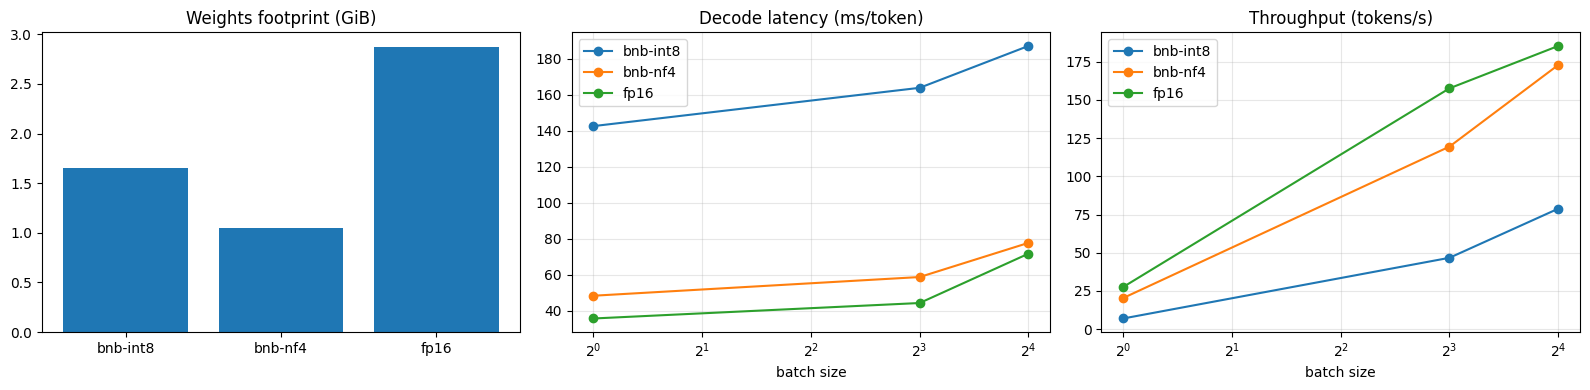

Zipped to /kaggle/working/llm-lab-exp2.zip


In [7]:
import shutil
import pandas as pd
import matplotlib.pyplot as plt

subprocess.run([sys.executable, str(ROOT / "src/quantize.py"), "summarize",
                "--results-dir", str(ROOT / "results"), "--out", str(ROOT / "results/quant_summary.csv")],
               check=True)

df = pd.read_csv(ROOT / "results/quant_summary.csv")
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
w = df.drop_duplicates("method")
axes[0].bar(w.method, w.weights_gib)
axes[0].set_title("Weights footprint (GiB)")
for m, g in df.dropna(subset=["decode_ms_per_token_mean"]).groupby("method"):
    axes[1].plot(g.batch_size, g.decode_ms_per_token_mean, marker="o", label=m)
    axes[2].plot(g.batch_size, g.throughput_tok_s_mean, marker="o", label=m)
axes[1].set_title("Decode latency (ms/token)")
axes[2].set_title("Throughput (tokens/s)")
for ax in axes[1:]:
    ax.set_xlabel("batch size")
    ax.set_xscale("log", base=2)
    ax.grid(alpha=0.3)
    ax.legend()
fig.tight_layout()
fig.savefig(ROOT / "plots/quant_overview.png", dpi=150)
plt.show()

shutil.make_archive("/kaggle/working/llm-lab-exp2", "zip", ROOT / "results")
print("Zipped to /kaggle/working/llm-lab-exp2.zip")